1. Import and setup

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("3_spotify_5000_songs.csv")

2. Load and explore the data

In [3]:
df.head()

,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
0,0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
3,3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
4,4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5235 entries, 0 to 5234
Data columns (total 19 columns):
 #   Column                                                                                                                                                                             Non-Null Count  Dtype  
---  ------                                                                                                                                                                             --------------  -----  
 0   Unnamed: 0                                                                                                                                                                         5235 non-null   int64  
 1   name                                                                                                                                                                               5235 non-null   object 
 2   artist                                                  

In [5]:
df.describe()

,Unnamed: 0,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,5235.00000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5.235000e+03,5235.000000
mean,2617.00000,0.509503,0.653565,5.254441,-9.338098,0.646227,0.083178,0.290043,0.257337,0.185354,0.443596,118.721407,2.479112e+05,3.902961
std,1511.35866,0.218041,0.288335,3.571559,6.294850,0.478185,0.071193,0.355985,0.370686,0.149410,0.277725,28.568463,1.356330e+05,0.420324
min,0.00000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.276000e+04,0.000000
25%,1308.50000,0.309000,0.479000,2.000000,-11.337000,0.000000,0.039000,0.002450,0.000001,0.092500,0.196000,96.174000,1.899910e+05,4.000000
50%,2617.00000,0.539000,0.738000,5.000000,-7.338000,1.000000,0.055800,0.095400,0.001880,0.125000,0.417000,119.180000,2.246670e+05,4.000000
75%,3925.50000,0.688000,0.893000,8.000000,-5.264000,1.000000,0.098650,0.565500,0.643000,0.237000,0.677000,134.019000,2.717200e+05,4.000000
max,5234.00000,0.967000,1.000000,11.000000,1.342000,1.000000,0.918000,0.996000,0.985000,0.987000,0.985000,213.990000,3.815787e+06,5.000000


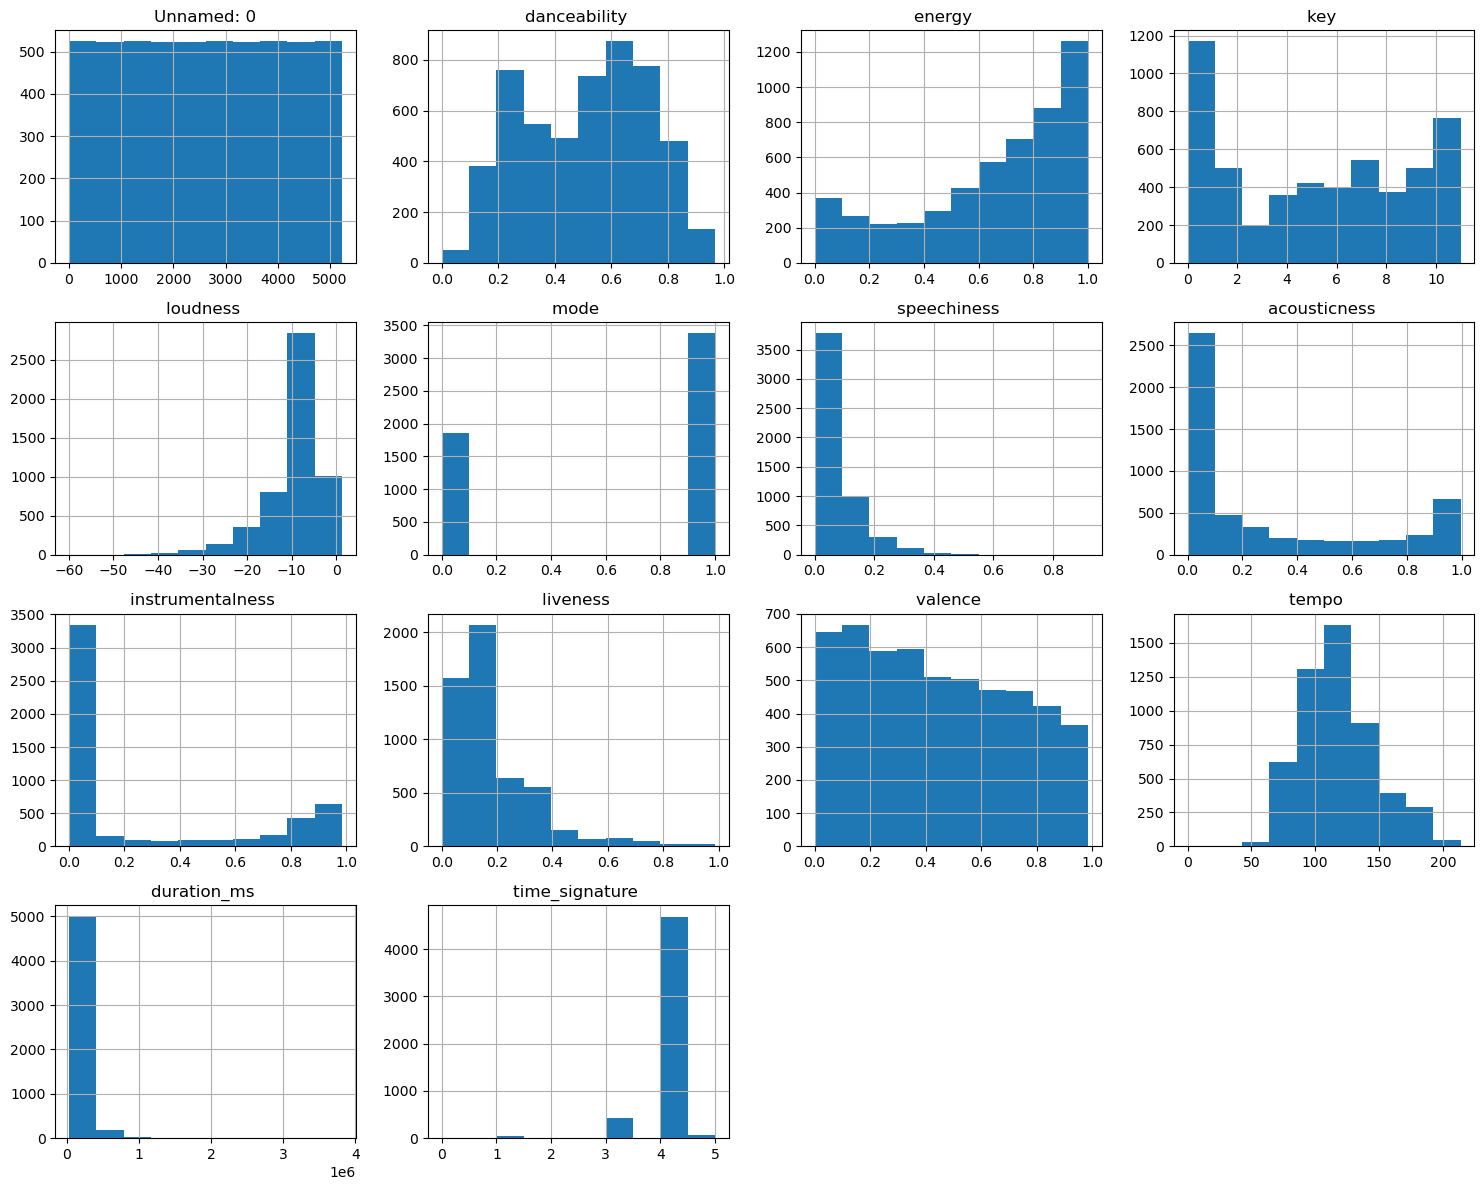

In [7]:
#inspect the distributions

df.hist(figsize=(15, 12))
plt.tight_layout()
plt.show()

duration_ms is very right-skewed with some extremely long tracks.
loudness is also skewed toward the higher end.
speechiness, acousticness, and instrumentalness are heavily concentrated near 0.
danceability, energy, valence, and tempo have more spread.
mode and time_signature are discrete rather than continuous features.
Unnamed: 0 is clearly just an index and isn't an audio characteristic.

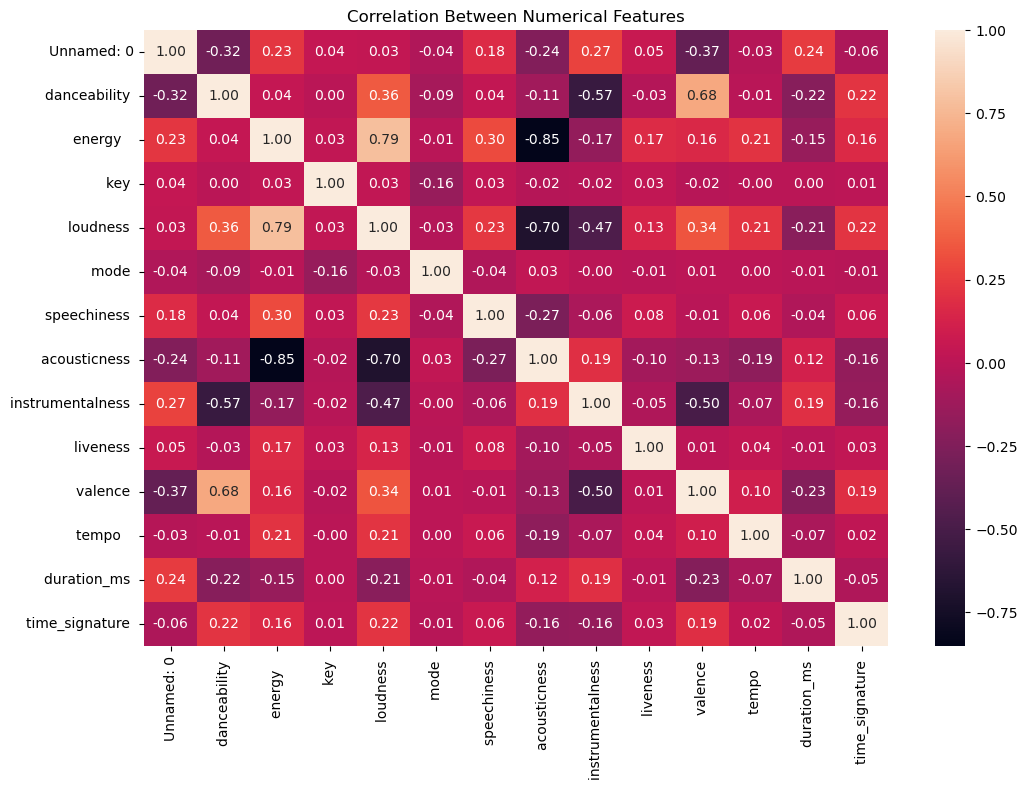

In [8]:
#inspect correlations
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")
plt.show()

energy ↔ loudness: 0.79 — strongly related
energy ↔ acousticness: -0.85 — strongly related
danceability ↔ valence: 0.68 — moderately strong
danceability ↔ instrumentalness: -0.57
loudness ↔ acousticness: -0.70


In [9]:
audio_features = df[
    [
        "danceability",
        "energy",
        "key",
        "loudness",
        "mode",
        "speechiness",
        "acousticness",
        "instrumentalness",
        "liveness",
        "valence",
        "tempo",
        "duration_ms",
        "time_signature"
    ]
].copy()

KeyError: "None of [Index(['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',\n       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',\n       'duration_ms', 'time_signature'],\n      dtype='object')] are in the [columns]"

In [10]:
df.columns

Index(['Unnamed: 0',
       'name                                                                                                                                                                             ',
       'artist                                          ', 'danceability ',
       'energy   ', 'key ', 'loudness ', 'mode ', 'speechiness ',
       'acousticness ', 'instrumentalness ', 'liveness ', 'valence ',
       'tempo   ', 'type ', 'duration_ms ', 'time_signature ',
       'id                     ', 'html'],
      dtype='object')

In [12]:
# Clean extra spaces from column names
df.columns = df.columns.str.strip()

In [13]:
df.columns

Index(['Unnamed: 0', 'name', 'artist', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'type', 'duration_ms', 'time_signature',
       'id', 'html'],
      dtype='object')

In [14]:
#create clustering features
audio_features = df[
    [
        "danceability",
        "energy",
        "key",
        "loudness",
        "mode",
        "speechiness",
        "acousticness",
        "instrumentalness",
        "liveness",
        "valence",
        "tempo",
        "duration_ms",
        "time_signature"
    ]
].copy()

In [15]:
audio_features.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,256213,4
1,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,191867,4
2,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,152267,4
3,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,186227,4
4,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,273680,4


3. Scale the features


In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_audio_features = scaler.fit_transform(audio_features)

In [17]:
scaled_audio_features = pd.DataFrame(
    scaled_audio_features,
    columns=audio_features.columns
)

scaled_audio_features.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0.680455,0.2590,1.000000,0.763897,0.0,0.076797,0.696787,0.000060,0.987842,0.310660,0.515800,0.059067,0.8
1,0.767322,0.3990,0.181818,0.771967,1.0,0.037691,0.217871,0.000002,0.108409,0.703553,0.584322,0.042058,0.8
2,0.880041,0.7300,0.181818,0.798018,1.0,0.377996,0.454819,0.000064,0.125633,0.918782,0.437862,0.031590,0.8
3,0.729059,0.0502,0.363636,0.682811,1.0,0.051307,0.882530,0.000041,0.391084,0.531980,0.499098,0.040567,0.8
4,0.673216,0.1190,0.545455,0.655228,1.0,0.041394,0.919679,0.000348,0.105370,0.408122,0.565171,0.063684,0.8


In [18]:
scaled_audio_features.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000
mean,0.526890,0.653565,0.477676,0.825893,0.646227,0.090608,0.291208,0.261255,0.187795,0.450352,0.554799,0.056873,0.780592
std,0.225482,0.288335,0.324687,0.102619,0.478185,0.077552,0.357414,0.376331,0.151378,0.281954,0.133504,0.035853,0.084065
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.319545,0.479000,0.181818,0.793306,0.000000,0.042484,0.002460,0.000001,0.093718,0.198985,0.449432,0.041562,0.800000
50%,0.557394,0.738000,0.454545,0.858498,1.000000,0.060784,0.095783,0.001909,0.126646,0.423350,0.556942,0.050728,0.800000
75%,0.711479,0.893000,0.727273,0.892309,1.000000,0.107462,0.567771,0.652792,0.240122,0.687310,0.626286,0.063166,0.800000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


scaled the 13 audio features to the same 0–1 range so that features such as duration and tempo don't dominate the K-Means distance calculation. The original df remains unchanged.

4. PCA


In [19]:
from sklearn.decomposition import PCA

In [20]:
pca = PCA()

pca.fit(scaled_audio_features)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [21]:
pca.explained_variance_ratio_

array([0.27948434, 0.26165474, 0.18337196, 0.11435786, 0.06083028,
       0.0276579 , 0.0226709 , 0.01778696, 0.01492237, 0.0073763 ,
       0.00603544, 0.00251644, 0.00133449])

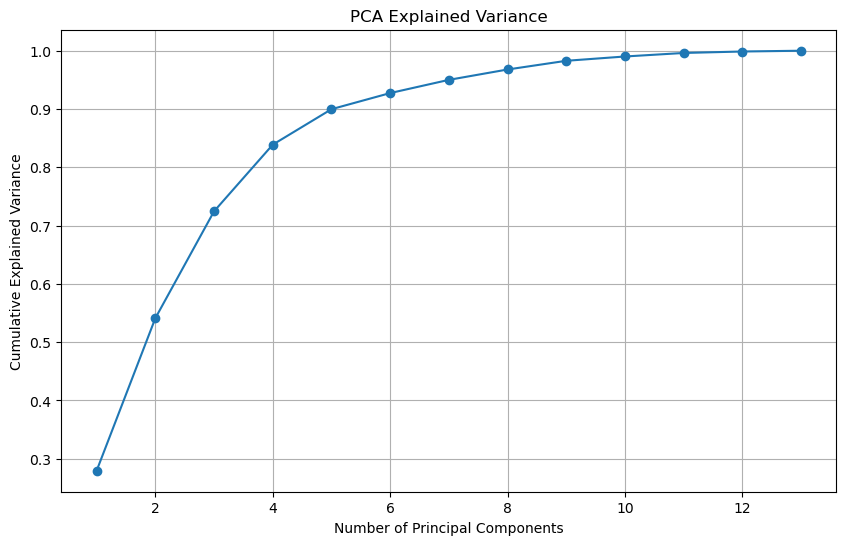

In [23]:
# use cumulative variance to decide how many components retain enough information.
cumulative_variance = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

5 components is a sensible starting point. We can preserve about 90% of the information while reducing the feature space from 13 dimensions to 5.

In [24]:
#Keep 90% of the total variance while reducing the number of dimensions.

pca = PCA(n_components=0.90)

pca_features = pca.fit_transform(scaled_audio_features)

pca_features.shape

(5235, 6)

In [25]:
#Give the principal components clear names so we can use them later.

pca_df = pd.DataFrame(
    pca_features,
    columns=[f"PC{i}" for i in range(1, pca_features.shape[1] + 1)]
)

pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6
0,-0.094419,-0.757884,0.504083,0.438636,-0.257086,0.554242
1,-0.017481,0.453019,0.384560,-0.225555,0.082847,-0.174383
2,-0.126719,0.504107,0.471724,-0.230476,0.276667,-0.007994
3,0.505367,0.184282,0.811681,-0.006984,-0.074671,0.106656
4,0.542908,0.131782,0.744387,0.172948,-0.151485,-0.082936


In [ ]:
# Verify that our PCA transformation retains approximately 90% of the information.

print("Number of components:", pca.n_components_)
print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Number of components: 6
Explained variance: [0.27948434 0.26165474 0.18337196 0.11435786 0.06083028 0.0276579 ]
Total explained variance: 0.9273570877580055


reduced 13 → 6 because the 13 features contain overlapping information. PCA found that 6 combined dimensions preserve 92.7% of the variance, so the reduction is substantial but not reckless.  Keep the original data.

5. choosing the number of clusters (K)

In [29]:
from sklearn.cluster import KMeans

inertia_list = []

#Test K values that could satisfy Moosic's 50–250 songs per playlist requirement.
for k in range(21, 105):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_features)
    inertia_list.append(kmeans.inertia_)

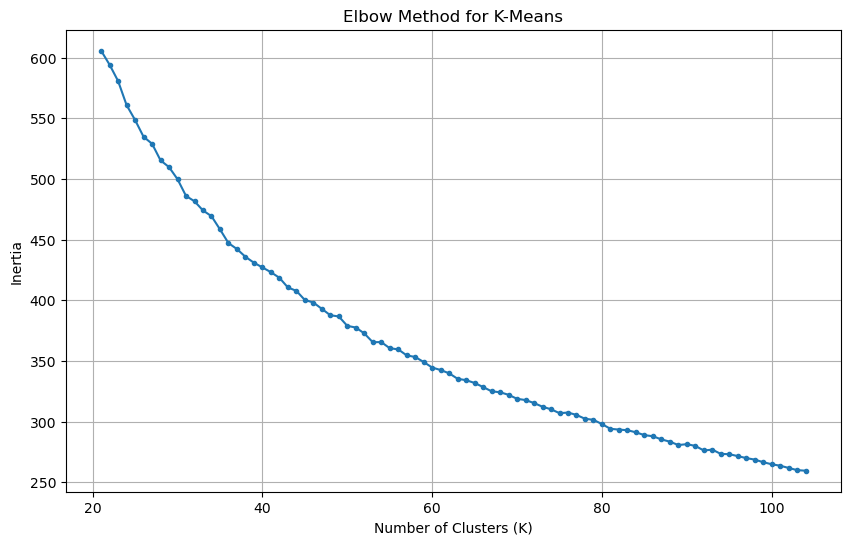

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(21, 105),
    inertia_list,
    marker="o",
    markersize=3
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.grid()
plt.show()

Increasing K beyond roughly 35–40 continues to improve compactness, but the improvement becomes progressively smaller.

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

#Silhouette scores help measure how well-separated and cohesive the clusters are.
for k in range(21, 105):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(pca_features)
    
    score = silhouette_score(pca_features, cluster_labels)
    silhouette_scores.append(score)

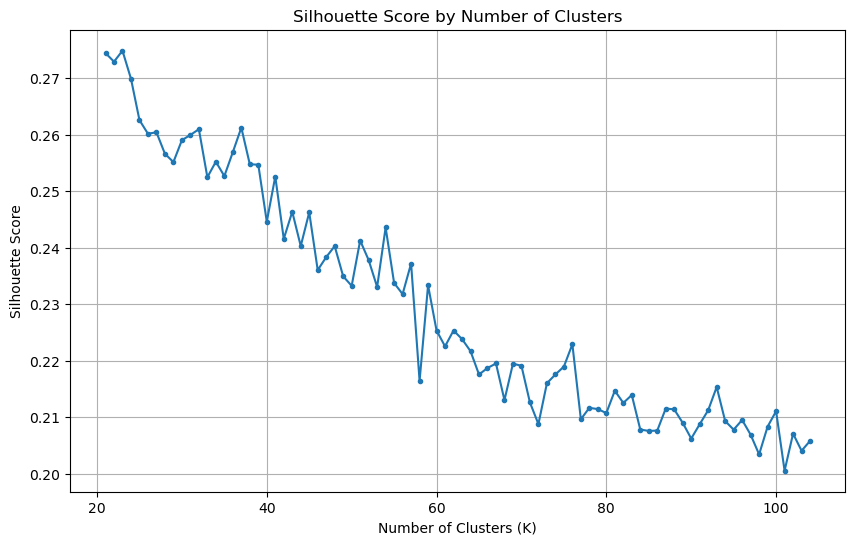

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(21, 105),
    silhouette_scores,
    marker="o",
    markersize=3
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.grid()
plt.show()

The Elbow Method did not provide a clear single optimal K. The Silhouette Method identified K=23 as the strongest solution within the business-valid range. At K=23, the average playlist would contain approximately 228 songs, which is within Moosic's required range of 50–250 songs. I will now check the actual cluster sizes before making the decision.

In [32]:
#K=23 was the strongest silhouette result within our business-valid range.

kmeans_23 = KMeans(
    n_clusters=23,
    random_state=42,
    n_init=10
)

cluster_labels_23 = kmeans_23.fit_predict(pca_features)

In [37]:
# Each row represents one cluster centroid in the 6-dimensional PCA space.

centroids = kmeans_23.cluster_centers_

print("Centroid shape:", centroids.shape)

Centroid shape: (23, 6)


In [ ]:
# Assign each song to the nearest centroid.

cluster_labels_23 = kmeans_23.labels_

print("Number of song assignments:", len(cluster_labels_23))

Number of song assignments: 5235


In [39]:
cluster_sizes = pd.Series(cluster_labels_23).value_counts().sort_index()

cluster_sizes

0     290
1     225
2     319
3     508
4     173
5     172
6     172
7      97
8     278
9     232
10    115
11    288
12    134
13    203
14    141
15    349
16    212
17    378
18     81
19    293
20    215
21    166
22    194
Name: count, dtype: int64

In [34]:
#Check whether every cluster satisfies Moosic's 50–250 song requirement.

print("Smallest cluster:", cluster_sizes.min())
print("Largest cluster:", cluster_sizes.max())
print("Number of clusters:", len(cluster_sizes))

print(
    "All clusters within 50–250 songs:",
    cluster_sizes.between(50, 250).all()
)

Smallest cluster: 81
Largest cluster: 508
Number of clusters: 23
All clusters within 50–250 songs: False


In [40]:
# Find which K values satisfy Moosic's playlist-size requirement.
# Every cluster must contain between 50 and 250 songs.

valid_k = []

for k in range(21, 105):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(pca_features)
    sizes = pd.Series(labels).value_counts()
    
    if sizes.min() >= 50 and sizes.max() <= 250:
        valid_k.append(k)

print("K values where ALL clusters contain 50–250 songs:")
print(valid_k)

K values where ALL clusters contain 50–250 songs:
[]


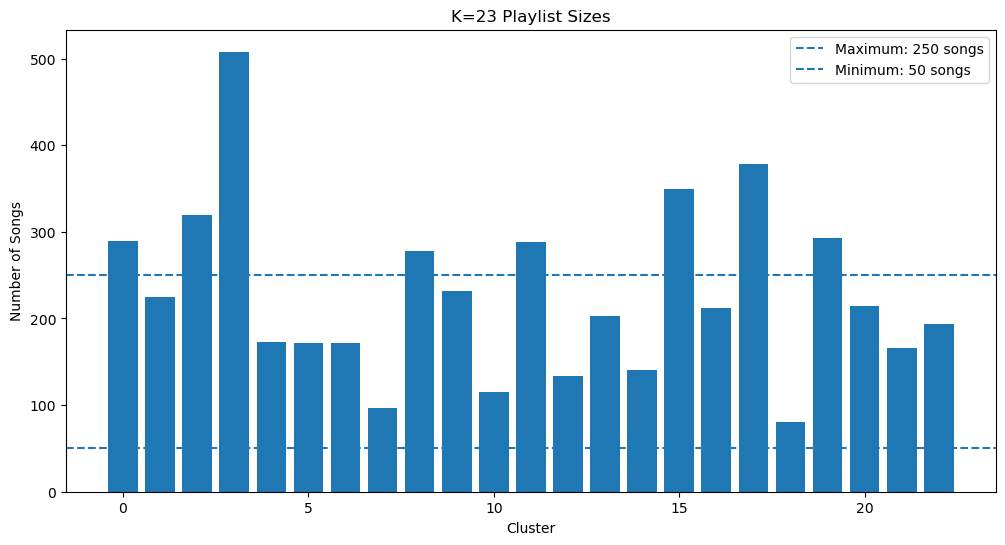

In [44]:
plt.figure(figsize=(12, 6))

plt.bar(
    cluster_sizes.index,
    cluster_sizes.values
)

plt.axhline(250, linestyle="--", label="Maximum: 250 songs")
plt.axhline(50, linestyle="--", label="Minimum: 50 songs")

plt.xlabel("Cluster")
plt.ylabel("Number of Songs")
plt.title("K=23 Playlist Sizes")
plt.legend()
plt.show()

K-Means with K=23 successfully grouped all 5,235 songs into 23 clusters, but the resulting playlist sizes are uneven. While the smallest cluster contains 81 songs, the largest contains 508 songs, exceeding Moosic's maximum of 250 songs. Testing all business-valid K values confirmed that standard K-Means cannot satisfy the playlist-size constraint on its own.

6. Handling the playlist-size contraint


In [45]:
#identify which K=23 clusters exceed Moosic's 250-song maximum.

oversized_clusters = cluster_sizes[cluster_sizes > 250]

oversized_clusters

0     290
2     319
3     508
8     278
11    288
15    349
17    378
19    293
Name: count, dtype: int64

In [46]:
# count how many playlists currently exceed the business limit.

print("Number of oversized clusters:", len(oversized_clusters))
print("Songs in oversized clusters:", oversized_clusters.sum())

Number of oversized clusters: 8
Songs in oversized clusters: 2703


The K=23 solution contains 8 oversized clusters, containing 2,703 songs in total. These clusters must be refined before the playlists can satisfy Moosic's 50–250 song requirement.

In [49]:
import math

# calculate the minimum number of sub-clusters
# needed to bring every oversized cluster below 250 songs.

split_plan = {}

for cluster, size in oversized_clusters.items():
    n_subclusters = math.ceil(size / 250)
    split_plan[cluster] = n_subclusters

split_plan

{0: 2, 2: 2, 3: 3, 8: 2, 11: 2, 15: 2, 17: 2, 19: 2}

In [50]:
# show the proposed split for each oversized cluster.

for cluster, size in oversized_clusters.items():
    n_subclusters = split_plan[cluster]
    
    print(
        f"Cluster {cluster}: {size} songs → "
        f"split into {n_subclusters} sub-clusters"
    )

Cluster 0: 290 songs → split into 2 sub-clusters
Cluster 2: 319 songs → split into 2 sub-clusters
Cluster 3: 508 songs → split into 3 sub-clusters
Cluster 8: 278 songs → split into 2 sub-clusters
Cluster 11: 288 songs → split into 2 sub-clusters
Cluster 15: 349 songs → split into 2 sub-clusters
Cluster 17: 378 songs → split into 2 sub-clusters
Cluster 19: 293 songs → split into 2 sub-clusters


calculated the minimum number of sub-clusters required for each oversized cluster based on Moosic's 250-song maximum. Most oversized clusters require two sub-clusters, while the 508-song cluster requires three. This gives a mathematically justified starting point for the split strategy rather than choosing the number arbitrarily.

In [51]:
# split only oversized clusters.
# Clusters that already satisfy the 50–250 requirement remain unchanged.

final_labels = cluster_labels_23.copy()

for cluster, n_subclusters in split_plan.items():
    
    # Get the songs belonging to this oversized cluster
    cluster_indices = np.where(cluster_labels_23 == cluster)[0]
    
    # Get their PCA features
    cluster_data = pca_features[cluster_indices]
    
    # Re-cluster the oversized group
    sub_kmeans = KMeans(
        n_clusters=n_subclusters,
        random_state=42,
        n_init=10
    )
    
    sub_labels = sub_kmeans.fit_predict(cluster_data)
    
    # Create new unique labels for the sub-clusters
    for sub_cluster in range(n_subclusters):
        new_label = f"{cluster}_{sub_cluster}"
        indices = cluster_indices[sub_labels == sub_cluster]
        final_labels[indices] = new_label

In [52]:
final_cluster_sizes = pd.Series(final_labels).value_counts().sort_index()

final_cluster_sizes

0      126
1      389
4      173
5      172
6      172
7       97
9      232
10     115
12     134
13     203
14     141
16     212
18      81
20     371
21     329
22     194
30     145
31     181
32     182
80     213
81      65
110    218
111     70
150    195
151    154
170    223
171    155
190    180
191    113
Name: count, dtype: int64

In [53]:
#evaluate whether the first split satisfies the business requirement.

print("Number of final playlists:", len(final_cluster_sizes))
print("Smallest playlist:", final_cluster_sizes.min())
print("Largest playlist:", final_cluster_sizes.max())

print(
    "All playlists within 50–250 songs:",
    final_cluster_sizes.between(50, 250).all()
)

Number of final playlists: 29
Smallest playlist: 65
Largest playlist: 389
All playlists within 50–250 songs: False


In [54]:
# Check the data type and unique final labels.

print(final_labels.dtype)
print(sorted(set(final_labels), key=str))

int32
[np.int32(0), np.int32(1), np.int32(10), np.int32(110), np.int32(111), np.int32(12), np.int32(13), np.int32(14), np.int32(150), np.int32(151), np.int32(16), np.int32(170), np.int32(171), np.int32(18), np.int32(190), np.int32(191), np.int32(20), np.int32(21), np.int32(22), np.int32(30), np.int32(31), np.int32(32), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(80), np.int32(81), np.int32(9)]


In [55]:
# identify the exact final cluster labels that still exceed 250 songs.

remaining_oversized = final_cluster_sizes[final_cluster_sizes > 250]

remaining_oversized

1     389
20    371
21    329
Name: count, dtype: int64

In [56]:
# calculate how many sub-clusters each remaining oversized playlist needs.

remaining_split_plan = {}

for cluster, size in remaining_oversized.items():
    n_subclusters = math.ceil(size / 250)
    remaining_split_plan[cluster] = n_subclusters

remaining_split_plan

{1: 2, 20: 2, 21: 2}

In [57]:
# split only the three playlists that still exceed 250 songs.

for cluster, n_subclusters in remaining_split_plan.items():

    # Find songs belonging to this oversized playlist
    cluster_indices = np.where(final_labels == cluster)[0]

    # Get their PCA features
    cluster_data = pca_features[cluster_indices]

    # Re-cluster this playlist
    sub_kmeans = KMeans(
        n_clusters=n_subclusters,
        random_state=42,
        n_init=10
    )

    sub_labels = sub_kmeans.fit_predict(cluster_data)

    # Give the new sub-clusters unique labels
    for sub_cluster in range(n_subclusters):
        indices = cluster_indices[sub_labels == sub_cluster]
        final_labels[indices] = cluster * 10 + sub_cluster

In [58]:
# recalculate playlist sizes after the second split.

final_cluster_sizes = pd.Series(final_labels).value_counts().sort_index()

print("Number of final playlists:", len(final_cluster_sizes))
print("Smallest playlist:", final_cluster_sizes.min())
print("Largest playlist:", final_cluster_sizes.max())

print(
    "All playlists within 50–250 songs:",
    final_cluster_sizes.between(50, 250).all()
)

Number of final playlists: 31
Smallest playlist: 65
Largest playlist: 340
All playlists within 50–250 songs: False


In [59]:
# identify any playlists that still exceed 250 songs.

remaining_oversized = final_cluster_sizes[final_cluster_sizes > 250]

remaining_oversized

10    340
Name: count, dtype: int64

In [60]:
# split the final oversized playlist into 2 smaller groups.

cluster = 10
n_subclusters = 2

cluster_indices = np.where(final_labels == cluster)[0]
cluster_data = pca_features[cluster_indices]

sub_kmeans = KMeans(
    n_clusters=n_subclusters,
    random_state=42,
    n_init=10
)

sub_labels = sub_kmeans.fit_predict(cluster_data)

# Give the two new playlists unique labels.
for sub_cluster in range(n_subclusters):
    indices = cluster_indices[sub_labels == sub_cluster]
    final_labels[indices] = 100 + sub_cluster

In [61]:


final_cluster_sizes = pd.Series(final_labels).value_counts().sort_index()

print("Number of final playlists:", len(final_cluster_sizes))
print("Smallest playlist:", final_cluster_sizes.min())
print("Largest playlist:", final_cluster_sizes.max())

print(
    "All playlists within 50–250 songs:",
    final_cluster_sizes.between(50, 250).all()
)

Number of final playlists: 32
Smallest playlist: 65
Largest playlist: 232
All playlists within 50–250 songs: True


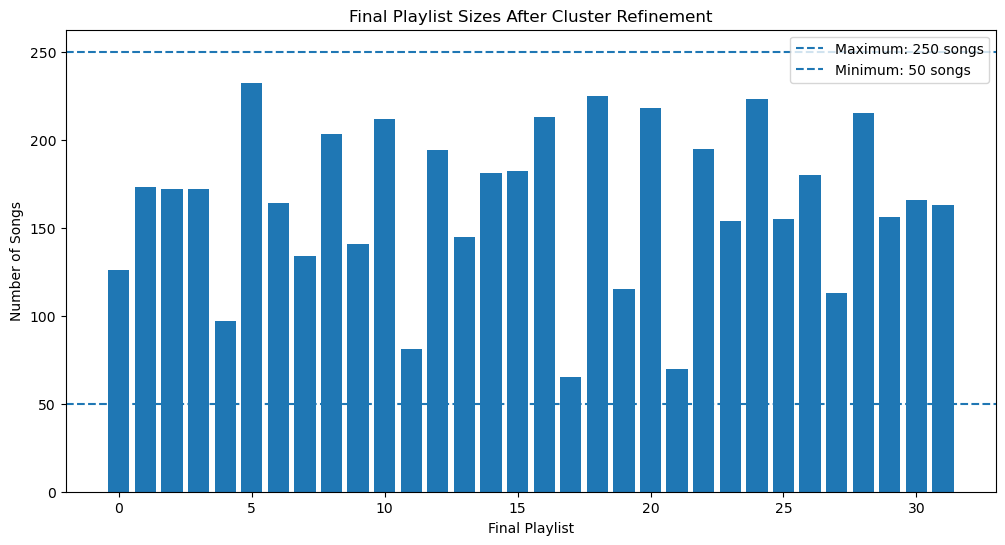

In [62]:
# Visualize the final playlist sizes after the split-and-refine process.

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(final_cluster_sizes)),
    final_cluster_sizes.values
)

plt.axhline(
    250,
    linestyle="--",
    label="Maximum: 250 songs"
)

plt.axhline(
    50,
    linestyle="--",
    label="Minimum: 50 songs"
)

plt.xlabel("Final Playlist")
plt.ylabel("Number of Songs")
plt.title("Final Playlist Sizes After Cluster Refinement")
plt.legend()
plt.show()

Standard K-Means alone could not satisfy the playlist-size requirement.  therefore I retained the technically motivated K=23 starting solution and iteratively split only oversized clusters until every final playlist contained between 50 and 250 songs.

7. Evaluating playlist coherence

In [63]:
from sklearn.metrics import silhouette_score

# evaluate how well-separated and internally coherent
# our final playlists are.

final_silhouette = silhouette_score(
    pca_features,
    final_labels
)

print("Final silhouette score:", final_silhouette)

Final silhouette score: 0.22448465518545313


In [64]:
from sklearn.metrics import silhouette_samples

# Calculate a silhouette score for every individual song.
# evaluate the coherence of each playlist separately.

sample_silhouette = silhouette_samples(
    pca_features,
    final_labels
)

silhouette_df = pd.DataFrame({
    "cluster": final_labels,
    "silhouette": sample_silhouette
})

playlist_silhouette = (
    silhouette_df
    .groupby("cluster")["silhouette"]
    .mean()
    .sort_values()
)

playlist_silhouette

cluster
9      0.062069
101    0.068831
150    0.093125
171    0.115909
201    0.131864
16     0.143830
13     0.144087
111    0.144877
200    0.146644
0      0.156184
30     0.156556
31     0.186467
7      0.190413
11     0.194608
32     0.199357
81     0.200446
170    0.209877
210    0.226385
190    0.238653
151    0.248540
5      0.252093
18     0.254290
14     0.264593
211    0.265187
12     0.292728
110    0.295752
4      0.308973
22     0.328207
191    0.331685
80     0.365302
6      0.407078
100    0.456395
Name: silhouette, dtype: float64

In [ ]:
# find the least and most coherent playlists.

print("Least coherent playlists:")
print(playlist_silhouette.head())

print("\nMost coherent playlists:")
print(playlist_silhouette.tail())

Least coherent playlists:
cluster
9      0.062069
101    0.068831
150    0.093125
171    0.115909
201    0.131864
Name: silhouette, dtype: float64

Most coherent playlists:
cluster
22     0.328207
191    0.331685
80     0.365302
6      0.407078
100    0.456395
Name: silhouette, dtype: float64


In [66]:
# why its songs may not form a strong musical group.

worst_cluster = playlist_silhouette.index[0]

print("Least coherent playlist:", worst_cluster)
print("Silhouette score:", playlist_silhouette.iloc[0])

Least coherent playlist: 9
Silhouette score: 0.06206918113043313


In [67]:
# show the songs belonging to the least coherent playlist.

worst_songs = df.loc[
    final_labels == worst_cluster,
    ["name", "artist"]
]

worst_songs.head(20)

,name,artist
1,Saudade De Bahia ...,Antônio Carlos Jobim
9,Previsao ...,Bossacucanova
13,Samba de Verão ...,Marcos Valle
20,Águas De Março ...,Antônio Carlos Jobim
23,Don't Stop the Carnival ...,Sonny Rollins
27,"Brigas, Nunca Mais ...",João Gilberto
28,Aquarela Do Brasil ...,Gal Costa
43,Saudade Fez Um Samba ...,João Gilberto
50,País Tropical ...,Wilson Simonal
52,Pais Tropical ...,Sergio Mendes & Brasil '66


Cluster 9 is particularly interesting because human inspection suggests a recognizable musical theme despite its very low silhouette score (0.062).

The low silhouette score does not necessarily mean the playlist is musically bad. It may mean that Spotify's numerical audio features don't fully capture the human-perceived relationship between these songs.

In [68]:
# compare the average audio-feature profiles
# of the least and most coherent playlists.

comparison_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

comparison_df = df.copy()
comparison_df["cluster"] = final_labels

playlist_profiles = comparison_df.groupby("cluster")[comparison_features].mean()

playlist_profiles.loc[[9, 100]]

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
9,0.619966,0.549871,-9.303164,0.063006,0.584017,0.038112,0.209002,0.717108,119.233664
100,0.326376,0.136818,-21.944138,0.044686,0.921449,0.876360,0.131649,0.166570,102.447169


In [69]:
# Scale the audio features for the radar chart.
# use the same features that were used for our clustering/PCA workflow.

from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

comparison_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

scaler_radar = MinMaxScaler()

scaled_radar = scaler_radar.fit_transform(
    df[comparison_features]
)

scaled_radar_df = pd.DataFrame(
    scaled_radar,
    columns=comparison_features,
    index=df.index
)

scaled_radar_df["cluster"] = final_labels

# Calculate average scaled feature values for the two playlists
radar_profiles = (
    scaled_radar_df
    .groupby("cluster")[comparison_features]
    .mean()
)

radar_profiles.loc[[9, 100]]

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
9,0.641123,0.549871,0.826462,0.068634,0.586363,0.038692,0.211755,0.728028,0.557193
100,0.337514,0.136818,0.620388,0.048677,0.925149,0.889706,0.133383,0.169107,0.478747


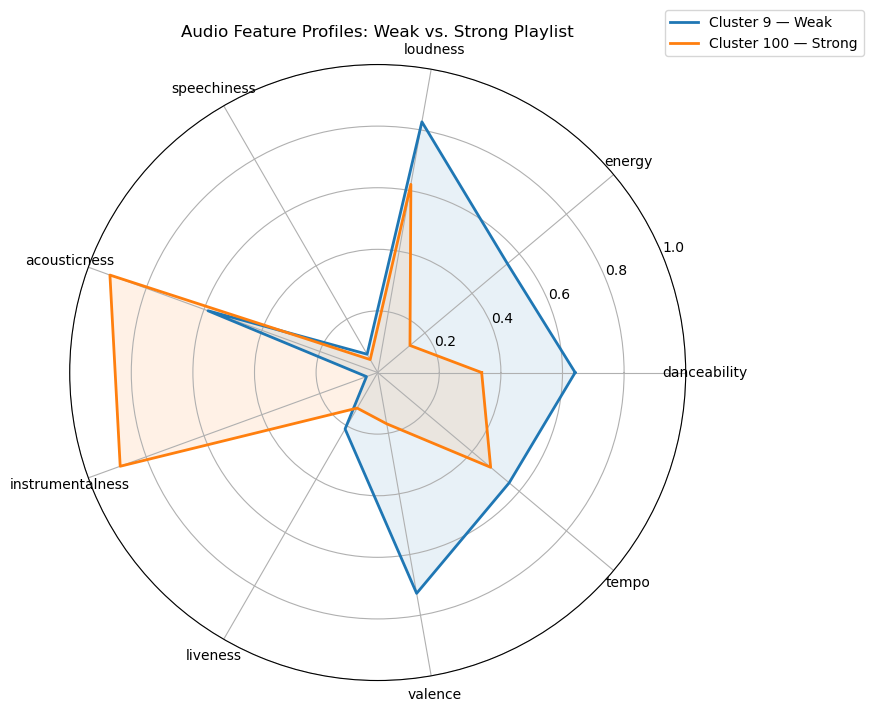

In [70]:
# compare the weak and strong playlists visually.

features = comparison_features
angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw=dict(polar=True)
)

for cluster, label in [(9, "Cluster 9 — Weak"), (100, "Cluster 100 — Strong")]:
    
    values = radar_profiles.loc[cluster].tolist()
    values += values[:1]
    
    ax.plot(angles, values, linewidth=2, label=label)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features)

ax.set_ylim(0, 1)
ax.set_title(
    "Audio Feature Profiles: Weak vs. Strong Playlist",
    pad=20
)

ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.show()

Cluster 100 has a much more distinctive audio profile, especially its very high acousticness and instrumentalness and low energy/valence. Cluster 9 has a broader profile, with higher danceability, energy and valence.

Overall silhouette score: 0.224

Most coherent playlist:
Cluster 100 → 0.456

Least coherent playlist:
Cluster 9 → 0.062

Key finding:
K-Means can create strongly cohesive playlists when songs
share distinctive measurable audio characteristics, but Spotify's
audio features do not capture all dimensions of human-perceived
musical similarity.

8. Understanding Spotify Features & Human Similarity

In [71]:
# examine which Spotify audio features contribute most
# to each principal component.

pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=audio_features.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

pca_loadings

,PC1,PC2,PC3,PC4,PC5,PC6
danceability,-0.243161,0.074682,0.318384,-0.021372,0.315144,-0.367505
energy,-0.387404,0.177936,-0.431587,-0.017108,0.045811,0.274806
key,-0.093200,-0.160245,-0.030623,0.980458,0.056324,-0.012880
loudness,-0.156147,0.068245,-0.054081,-0.003707,-0.012152,0.043640
mode,0.408183,0.892739,-0.023551,0.182428,0.023668,-0.022992
speechiness,-0.035041,0.008749,-0.037933,0.001055,-0.017807,0.017827
acousticness,0.506676,-0.215695,0.538274,0.036296,-0.003379,0.312055
instrumentalness,0.489651,-0.251898,-0.537780,-0.046981,0.616474,-0.041479
liveness,-0.034804,0.012428,-0.036535,0.011498,-0.050288,0.771404
valence,-0.296890,0.155756,0.353149,-0.031122,0.714285,0.234739


In [72]:


absolute_loadings = pca_loadings.abs()

absolute_loadings

,PC1,PC2,PC3,PC4,PC5,PC6
danceability,0.243161,0.074682,0.318384,0.021372,0.315144,0.367505
energy,0.387404,0.177936,0.431587,0.017108,0.045811,0.274806
key,0.093200,0.160245,0.030623,0.980458,0.056324,0.012880
loudness,0.156147,0.068245,0.054081,0.003707,0.012152,0.043640
mode,0.408183,0.892739,0.023551,0.182428,0.023668,0.022992
speechiness,0.035041,0.008749,0.037933,0.001055,0.017807,0.017827
acousticness,0.506676,0.215695,0.538274,0.036296,0.003379,0.312055
instrumentalness,0.489651,0.251898,0.537780,0.046981,0.616474,0.041479
liveness,0.034804,0.012428,0.036535,0.011498,0.050288,0.771404
valence,0.296890,0.155756,0.353149,0.031122,0.714285,0.234739


In [73]:
# show the three strongest features contributing
# to each principal component.

for pc in absolute_loadings.columns:
    print(f"\n{pc}")
    print(
        absolute_loadings[pc]
        .sort_values(ascending=False)
        .head(3)
    )


PC1
acousticness        0.506676
instrumentalness    0.489651
mode                0.408183
Name: PC1, dtype: float64

PC2
mode                0.892739
instrumentalness    0.251898
acousticness        0.215695
Name: PC2, dtype: float64

PC3
acousticness        0.538274
instrumentalness    0.537780
energy              0.431587
Name: PC3, dtype: float64

PC4
key                 0.980458
mode                0.182428
instrumentalness    0.046981
Name: PC4, dtype: float64

PC5
valence             0.714285
instrumentalness    0.616474
danceability        0.315144
Name: PC5, dtype: float64

PC6
liveness        0.771404
danceability    0.367505
acousticness    0.312055
Name: PC6, dtype: float64


PCA shows that the main structure in the dataset is driven primarily
by acousticness, instrumentalness, energy, valence, mode/key,
liveness and danceability.

This means Spotify's audio features provide useful information
for automatically grouping songs.

However, the low-coherence Cluster 9 demonstrates that audio
features alone cannot capture every dimension of similarity
that humans may perceive.

Conclusion:
Spotify audio features are useful for playlist generation,
but they should ideally be combined with additional information
such as genre, artist, language or listening behaviour.

In [ ]:
9. Cluster Profiles & Playlist Naming


In [ ]:
# create an average audio-feature profile for every
# final playlist to understand what each cluster represents.

profile_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

df_profiles = df.copy()
df_profiles["cluster"] = final_labels

cluster_profiles = (
    df_profiles
    .groupby("cluster")[profile_features]
    .mean()
)

cluster_profiles

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.598579,0.600992,-7.013714,0.076275,0.167486,0.014664,0.131383,0.324176,120.244452
4,0.319232,0.892780,-8.230110,0.103937,0.017244,0.773988,0.192777,0.261987,123.676861
5,0.300759,0.918703,-6.867291,0.121645,0.005570,0.121864,0.199417,0.186658,120.557017
6,0.302779,0.121784,-22.585483,0.043797,0.937820,0.856355,0.136732,0.154538,102.471866
7,0.621443,0.479499,-9.647340,0.087565,0.594876,0.021576,0.166857,0.568416,119.198052
9,0.619966,0.549871,-9.303164,0.063006,0.584017,0.038112,0.209002,0.717108,119.233664
11,0.557805,0.810402,-5.557744,0.083294,0.049153,0.020282,0.198810,0.468159,126.233787
12,0.357060,0.868933,-7.841306,0.089143,0.031582,0.804216,0.212127,0.277803,122.533381
13,0.435004,0.869276,-5.786852,0.105506,0.024151,0.059853,0.238454,0.241789,124.883025


In [75]:
# combine each playlist's musical profile with
# its number of songs.

cluster_profiles["song_count"] = final_cluster_sizes

cluster_profiles

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,song_count
cluster,,,,,,,,,,
0,0.598579,0.600992,-7.013714,0.076275,0.167486,0.014664,0.131383,0.324176,120.244452,126
4,0.319232,0.892780,-8.230110,0.103937,0.017244,0.773988,0.192777,0.261987,123.676861,173
5,0.300759,0.918703,-6.867291,0.121645,0.005570,0.121864,0.199417,0.186658,120.557017,172
6,0.302779,0.121784,-22.585483,0.043797,0.937820,0.856355,0.136732,0.154538,102.471866,172
7,0.621443,0.479499,-9.647340,0.087565,0.594876,0.021576,0.166857,0.568416,119.198052,97
9,0.619966,0.549871,-9.303164,0.063006,0.584017,0.038112,0.209002,0.717108,119.233664,232
11,0.557805,0.810402,-5.557744,0.083294,0.049153,0.020282,0.198810,0.468159,126.233787,164
12,0.357060,0.868933,-7.841306,0.089143,0.031582,0.804216,0.212127,0.277803,122.533381,134
13,0.435004,0.869276,-5.786852,0.105506,0.024151,0.059853,0.238454,0.241789,124.883025,203


In [76]:
# identify the three strongest audio characteristics
# for each playlist.

for cluster in cluster_profiles.index:
    
    profile = cluster_profiles.loc[cluster, profile_features]
    
    strongest = profile.sort_values(ascending=False).head(3)
    
    print(f"\nPlaylist {cluster} ({cluster_profiles.loc[cluster, 'song_count']} songs)")
    print(strongest)


Playlist 0 (126 songs)
tempo           120.244452
energy            0.600992
danceability      0.598579
Name: 0, dtype: float64

Playlist 4 (173 songs)
tempo               123.676861
energy                0.892780
instrumentalness      0.773988
Name: 4, dtype: float64

Playlist 5 (172 songs)
tempo           120.557017
energy            0.918703
danceability      0.300759
Name: 5, dtype: float64

Playlist 6 (172 songs)
tempo               102.471866
acousticness          0.937820
instrumentalness      0.856355
Name: 6, dtype: float64

Playlist 7 (97 songs)
tempo           119.198052
danceability      0.621443
acousticness      0.594876
Name: 7, dtype: float64

Playlist 9 (232 songs)
tempo           119.233664
valence           0.717108
danceability      0.619966
Name: 9, dtype: float64

Playlist 11 (164 songs)
tempo           126.233787
energy            0.810402
danceability      0.557805
Name: 11, dtype: float64

Playlist 12 (134 songs)
tempo               122.533381
energy          

The final clusters can be translated from technical cluster IDs into meaningful playlist profiles, providing a practical bridge between the machine-learning results and Moosic's end-user experience.

In [81]:
# create descriptive playlist names from the
# musical characteristics of each final cluster.

def name_playlist(row):
    
    if row["acousticness"] > 0.85 and row["instrumentalness"] > 0.75:
        return "Acoustic Instrumentals"
    
    elif row["acousticness"] > 0.75 and row["energy"] < 0.35:
        return "Acoustic Chill"
    
    elif row["instrumentalness"] > 0.75 and row["energy"] > 0.80:
        return "High-Energy Instrumentals"
    
    elif row["danceability"] > 0.70 and row["valence"] > 0.75:
        return "Feel-Good Dance"
    
    elif row["danceability"] > 0.65 and row["energy"] > 0.65:
        return "Upbeat Grooves"
    
    elif row["energy"] > 0.75 and row["valence"] > 0.65:
        return "Energetic Feel-Good"
    
    elif row["acousticness"] > 0.55 and row["energy"] < 0.60:
        return "Mellow Acoustic"
    
    elif row["danceability"] > 0.55 and row["valence"] > 0.60:
        return "Happy Grooves"
    
    elif row["energy"] > 0.70:
        return "High-Energy Mix"
    
    else:
        return "Balanced Mix"

In [82]:
# Apply the naming rules to all final playlist profiles.

cluster_profiles["playlist_name"] = cluster_profiles.apply(
    name_playlist,
    axis=1
)

cluster_profiles[
    ["playlist_name", "song_count"]
]

,playlist_name,song_count
cluster,,
0,Balanced Mix,126
4,High-Energy Instrumentals,173
5,High-Energy Mix,172
6,Acoustic Instrumentals,172
7,Mellow Acoustic,97
9,Mellow Acoustic,232
11,High-Energy Mix,164
12,High-Energy Instrumentals,134
13,High-Energy Mix,203


In [83]:
# Make every playlist name unique while preserving
# the underlying musical category.

name_counts = {}

unique_names = []

for name in cluster_profiles["playlist_name"]:
    
    if name not in name_counts:
        name_counts[name] = 1
        unique_names.append(name)
    else:
        name_counts[name] += 1
        unique_names.append(
            f"{name} {name_counts[name]}"
        )

cluster_profiles["playlist_name"] = unique_names

cluster_profiles[["playlist_name", "song_count"]]

,playlist_name,song_count
cluster,,
0,Balanced Mix,126
4,High-Energy Instrumentals,173
5,High-Energy Mix,172
6,Acoustic Instrumentals,172
7,Mellow Acoustic,97
9,Mellow Acoustic 2,232
11,High-Energy Mix 2,164
12,High-Energy Instrumentals 2,134
13,High-Energy Mix 3,203


10. Final validation & business outcome


In [84]:
# compare the initial K-Means solution with our
# final refined playlist solution.

initial_summary = {
    "Number of playlists": len(cluster_sizes),
    "Smallest playlist": cluster_sizes.min(),
    "Largest playlist": cluster_sizes.max(),
    "All within 50–250": cluster_sizes.between(50, 250).all()
}

final_summary = {
    "Number of playlists": len(final_cluster_sizes),
    "Smallest playlist": final_cluster_sizes.min(),
    "Largest playlist": final_cluster_sizes.max(),
    "All within 50–250": final_cluster_sizes.between(50, 250).all()
}

comparison = pd.DataFrame(
    [initial_summary, final_summary],
    index=["Initial K-Means", "Final Solution"]
)

comparison

,Number of playlists,Smallest playlist,Largest playlist,All within 50–250
Initial K-Means,23,81,508,False
Final Solution,32,65,232,True


In [85]:
# final business validation.
# Every playlist must contain between 50 and 250 songs.

print(
    "All final playlists satisfy the 50–250 song requirement:",
    final_cluster_sizes.between(50, 250).all()
)

print("Number of final playlists:", len(final_cluster_sizes))
print("Smallest playlist:", final_cluster_sizes.min())
print("Largest playlist:", final_cluster_sizes.max())

All final playlists satisfy the 50–250 song requirement: True
Number of final playlists: 32
Smallest playlist: 65
Largest playlist: 232


In [86]:
# record the final clustering quality.

print(f"Final silhouette score: {final_silhouette:.3f}")

Final silhouette score: 0.224


The split-and-merge refinement successfully resolved the original cluster-size problem while preserving the full dataset. The resulting 32 playlists all meet Moosic's required size range of 50–250 songs, providing a practical and scalable playlist structure.

11. Final delivery

In [88]:
# combine each song with its final playlist ID
# and its user-facing playlist name.

final_delivery = df.copy()

final_delivery["playlist_id"] = final_labels

final_delivery["playlist_name"] = final_delivery["playlist_id"].map(
    cluster_profiles["playlist_name"]
)

final_delivery[
    ["name", "artist", "playlist_id", "playlist_name"]
].head()

,name,artist,playlist_id,playlist_name
0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,101,Mellow Acoustic 3
1,Saudade De Bahia ...,Antônio Carlos Jobim,9,Mellow Acoustic 2
2,"Canta Canta, Minha Gente ...",Martinho Da Vila,170,Feel-Good Dance 2
3,Mulher Eu Sei ...,Chico César,210,Acoustic Chill 3
4,Rosa Morena ...,Kurt Elling,14,Acoustic Chill


In [89]:
# every song must have a valid final playlist assignment.

print("Total songs:", len(final_delivery))
print("Songs with playlist names:", final_delivery["playlist_name"].notna().sum())
print(
    "All songs assigned:",
    final_delivery["playlist_name"].notna().all()
)

Total songs: 5235
Songs with playlist names: 5235
All songs assigned: True


In [90]:
# final delivery check — verify the number of songs
# assigned to each named playlist.

final_delivery["playlist_name"].value_counts().sort_index()

playlist_name
Acoustic Chill                 141
Acoustic Chill 2                81
Acoustic Chill 3               166
Acoustic Instrumentals         172
Acoustic Instrumentals 2       194
Acoustic Instrumentals 3       225
Balanced Mix                   126
Energetic Feel-Good            155
Feel-Good Dance                182
Feel-Good Dance 2              223
Feel-Good Dance 3              113
Feel-Good Dance 4              156
Happy Grooves                  215
High-Energy Instrumentals      173
High-Energy Instrumentals 2    134
High-Energy Instrumentals 3    213
High-Energy Instrumentals 4     65
High-Energy Instrumentals 5    218
High-Energy Instrumentals 6     70
High-Energy Mix                172
High-Energy Mix 2              164
High-Energy Mix 3              203
High-Energy Mix 4              212
High-Energy Mix 5              195
High-Energy Mix 6              154
Mellow Acoustic                 97
Mellow Acoustic 2              232
Mellow Acoustic 3              115
Upbeat

11.2 Visualizations


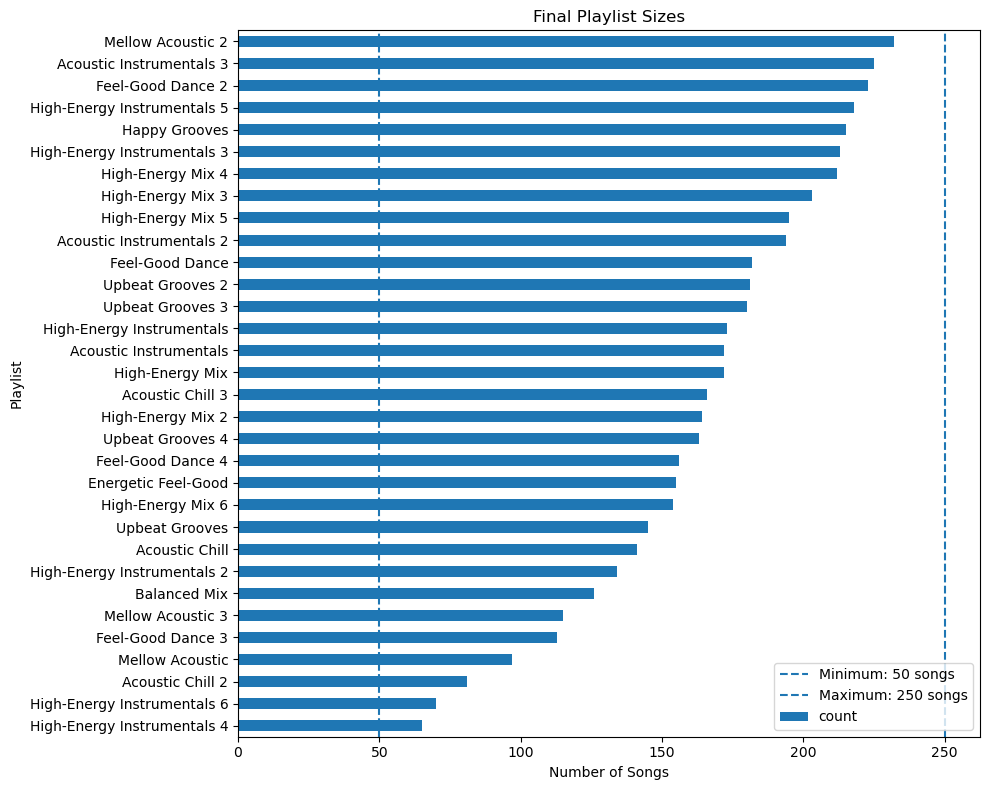

In [91]:
# visualize the size of every final playlist
# and check the 50–250 song business requirement.

import matplotlib.pyplot as plt

playlist_sizes = (
    final_delivery["playlist_name"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 8))
playlist_sizes.plot(kind="barh")

plt.axvline(50, linestyle="--", label="Minimum: 50 songs")
plt.axvline(250, linestyle="--", label="Maximum: 250 songs")

plt.xlabel("Number of Songs")
plt.ylabel("Playlist")
plt.title("Final Playlist Sizes")
plt.legend()
plt.tight_layout()
plt.show()

The final playlist-size distribution confirms that all 32 playlists comply with Moosic's 50–250 song requirement.

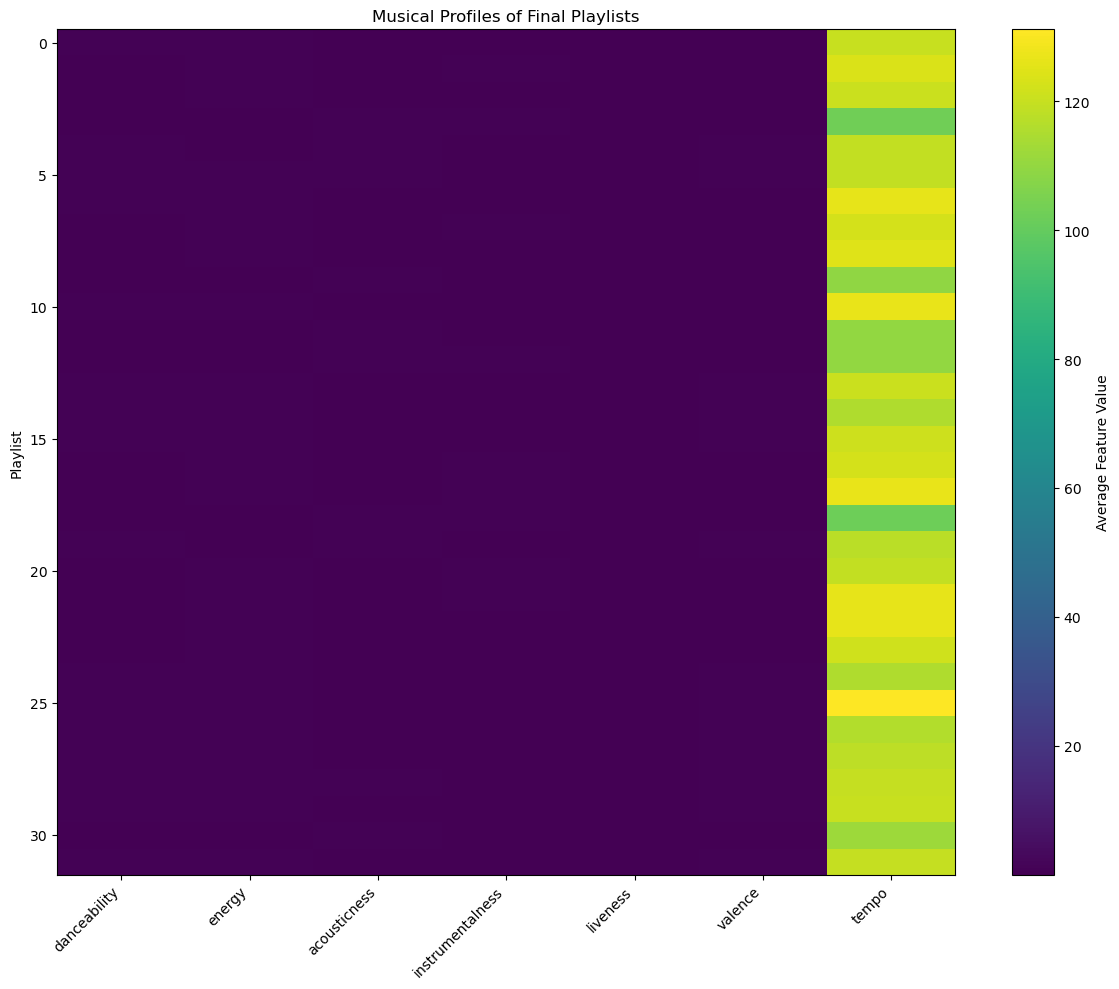

In [92]:
# visualize the musical characteristics of
# the final playlists.

profile_features = [
    "danceability",
    "energy",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

plt.figure(figsize=(12, 10))

plt.imshow(
    cluster_profiles[profile_features],
    aspect="auto"
)

plt.colorbar(label="Average Feature Value")
plt.xticks(
    range(len(profile_features)),
    profile_features,
    rotation=45,
    ha="right"
)

plt.ylabel("Playlist")
plt.title("Musical Profiles of Final Playlists")
plt.tight_layout()
plt.show()

The heatmap demonstrates that the final playlists have distinct combinations of acousticness, energy, danceability, instrumentalness and valence.

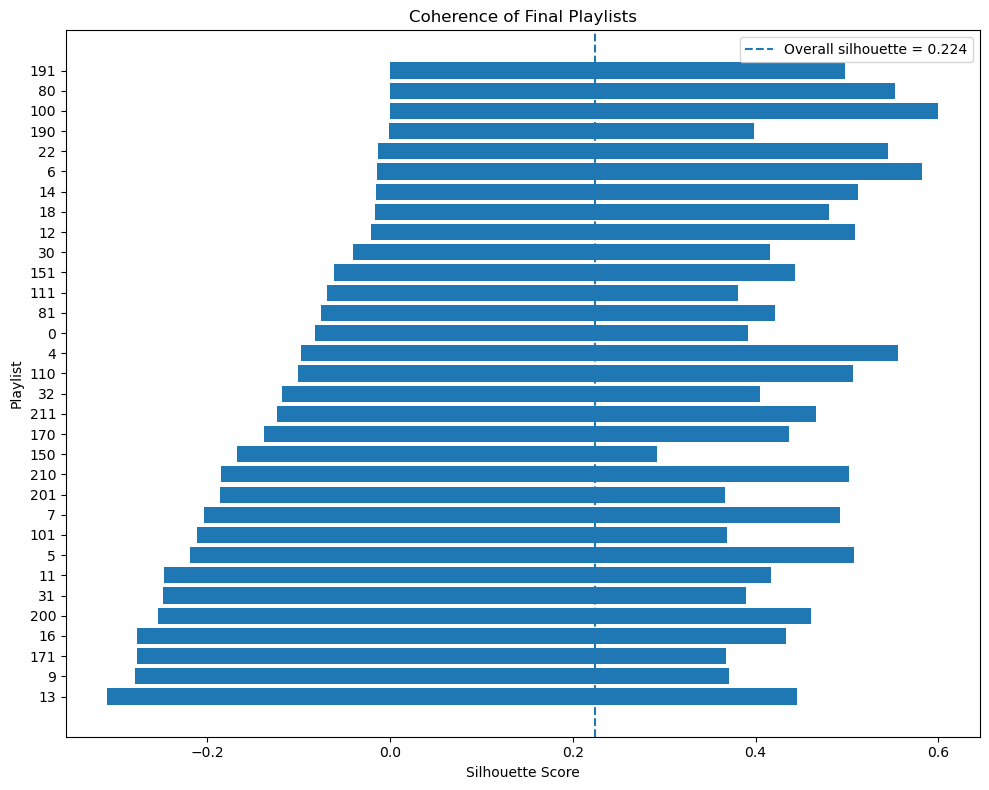

In [93]:
# visualize the coherence of each final playlist.

playlist_silhouette = (
    silhouette_df
    .sort_values("silhouette")
)

plt.figure(figsize=(10, 8))

plt.barh(
    playlist_silhouette["cluster"].astype(str),
    playlist_silhouette["silhouette"]
)

plt.axvline(
    final_silhouette,
    linestyle="--",
    label=f"Overall silhouette = {final_silhouette:.3f}"
)

plt.xlabel("Silhouette Score")
plt.ylabel("Playlist")
plt.title("Coherence of Final Playlists")
plt.legend()
plt.tight_layout()
plt.show()

Playlist-level silhouette scores show that coherence varies across the final playlists, while the overall silhouette score of approximately 0.224 indicates moderate separation between clusters.

## 12. Final Conclusion

The Moosic playlist segmentation project successfully transformed Spotify audio
features into a practical playlist recommendation structure.

After preprocessing and scaling the data, PCA was used to reduce the feature
space while retaining approximately 92.7% of the total variance. K-Means
clustering was then applied to identify groups of musically similar songs.

The initial clustering produced 23 clusters, but several exceeded Moosic's
business requirement of 50–250 songs per playlist. Instead of simply choosing
a different K value or removing songs, oversized clusters were selectively
split and refined.

The final solution contains 32 playlists, with playlist sizes ranging from
65 to 232 songs. Therefore, all final playlists satisfy the required
50–250 song range while retaining the complete dataset.

The final silhouette score was approximately 0.224, indicating moderate
cluster separation. Cluster-level analysis also showed interpretable
differences in characteristics such as danceability, energy, acousticness,
instrumentalness and valence.

Finally, each cluster was assigned a descriptive playlist name and exported
as a song-to-playlist dataset, providing a practical output that Moosic could
use for playlist creation.

In [96]:
# export the final playlist assignments.

final_delivery[
    ["name", "artist", "playlist_id", "playlist_name"]
].to_csv(
    "moosic_final_playlists.csv",
    index=False
)

print("Final playlist file exported successfully.")

Final playlist file exported successfully.


In [98]:
# Verify the final exported file contains all
# expected songs, playlists, and columns.

export_check = pd.read_csv("moosic_final_playlists.csv")

print("Total songs:", len(export_check))
print("Number of playlists:", export_check["playlist_name"].nunique())
print("Columns:", export_check.columns.tolist())
print(
    "All songs assigned:",
    export_check["playlist_name"].notna().all()
)

Total songs: 5235
Number of playlists: 32
Columns: ['name', 'artist', 'playlist_id', 'playlist_name']
All songs assigned: True


In [101]:
# check the original dataset size against the final export.

print("Original dataset:", len(df))
print("Final export:", len(export_check))
print("Difference:", len(export_check) - len(df))

Original dataset: 5235
Final export: 5235
Difference: 0
